## **Analysis and Forecasting of Australian Beer Production**

#### **The object of this exercise is to explore the Australian Beer Production dataset, which contains quarterly observations of beer production. The aim is to explore key time-series characteristics, such as trends, seasonality, and stationarity, and to develop forecasting models. Models are applied and evaluated to understand their effectiveness in forecasting the time series.**


## **1. Data Preparation**

### **Import the necessary libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### **Import the dataset and explore**

#### The dataset contains historical records of beer production in Australia measured quarterly. Each observation represents the total volume of beer produced within a specific quarter.

In [2]:
df = pd.read_csv("ausbeer.csv")
df.head()

,index,value
0,1956 Q1,284
1,1956 Q2,213
2,1956 Q3,227
3,1956 Q4,308
4,1957 Q1,262


In [3]:
# Rename columns
df = df.rename(columns={'index':'date', 'value':'beer_production'})
df.head()

,date,beer_production
0,1956 Q1,284
1,1956 Q2,213
2,1956 Q3,227
3,1956 Q4,308
4,1957 Q1,262


In [4]:
# Check column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             218 non-null    object
 1   beer_production  218 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [5]:
# Convert "1956 Q1" → "1956Q1"
df['date'] = df['date'].str.replace(' ', '')

# Convert to quarterly datetime
df['date'] = pd.PeriodIndex(df['date'], freq='Q').to_timestamp()

# Set as index
df.set_index('date', inplace=True)

df.head()

,beer_production
date,
1956-01-01,284
1956-04-01,213
1956-07-01,227
1956-10-01,308
1957-01-01,262


In [6]:
# Explicitly set quarterly frequency
df = df.asfreq('QS')

In [7]:
print(df.index)
print(type(df.index))

DatetimeIndex(['1956-01-01', '1956-04-01', '1956-07-01', '1956-10-01',
               '1957-01-01', '1957-04-01', '1957-07-01', '1957-10-01',
               '1958-01-01', '1958-04-01',
               ...
               '2008-01-01', '2008-04-01', '2008-07-01', '2008-10-01',
               '2009-01-01', '2009-04-01', '2009-07-01', '2009-10-01',
               '2010-01-01', '2010-04-01'],
              dtype='datetime64[ns]', name='date', length=218, freq='QS-JAN')
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [8]:
# Check the tail of the dataset
df.tail()

,beer_production
date,
2009-04-01,398
2009-07-01,419
2009-10-01,488
2010-01-01,414
2010-04-01,374


In [9]:
# Checking missing data
df.isnull().sum()

beer_production    0
dtype: int64

## **2. Exploratory Data Analysis**

In [10]:
# Summary statistics
print("Summary Statistics:")
print(df['beer_production'].describe())

Summary Statistics:
count    218.000000
mean     415.371560
std       85.880662
min      213.000000
25%      379.250000
50%      422.000000
75%      465.750000
max      599.000000
Name: beer_production, dtype: float64


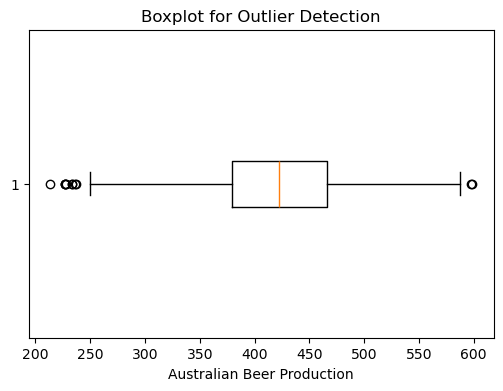

In [11]:
# Check outlayers  
plt.figure(figsize=(6, 4))
plt.boxplot(df['beer_production'], vert=False)
plt.title('Boxplot for Outlier Detection')
plt.xlabel('Australian Beer Production')
plt.show()


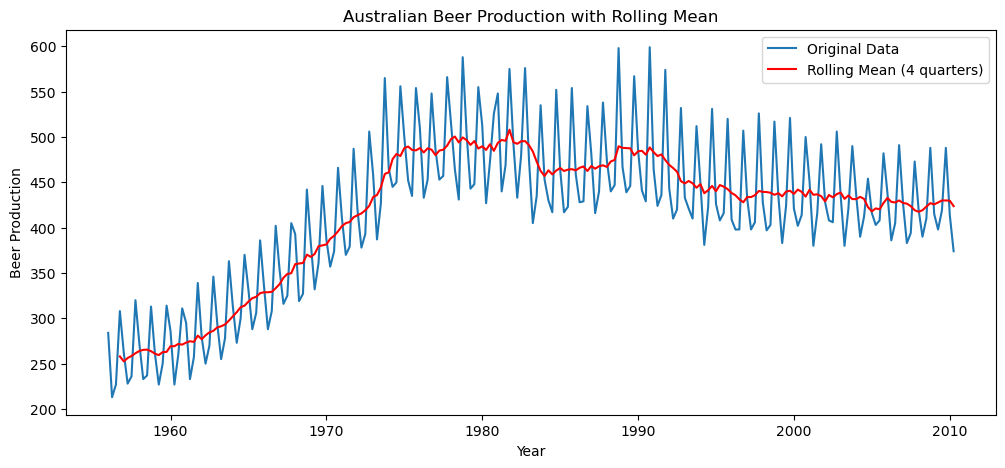

In [12]:
import matplotlib.pyplot as plt

# Calculate rolling mean (1 year for quarterly data)
df['rolling_mean'] = df['beer_production'].rolling(window=4).mean()

plt.figure(figsize=(12,5))

# Plot original series
plt.plot(df.index, df['beer_production'], label='Original Data')

# Plot rolling mean
plt.plot(df.index, df['rolling_mean'], color='red', label='Rolling Mean (4 quarters)')

plt.title('Australian Beer Production with Rolling Mean')
plt.xlabel('Year')
plt.ylabel('Beer Production')
plt.legend()

plt.show()

<Figure size 1200x500 with 0 Axes>

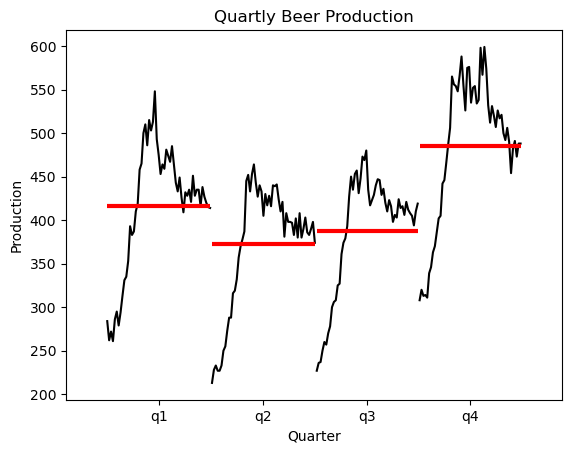

In [13]:
# Check the quarter seasonality (need to resample for quarterly)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
plt.figure(figsize=(12,5))
quarter_plot(df['beer_production'].resample('QE').mean())
plt.title('Quartly Beer Production')
plt.xlabel('Quarter')
plt.ylabel('Production')
plt.show()

**Seasonal Decomposition Plot**

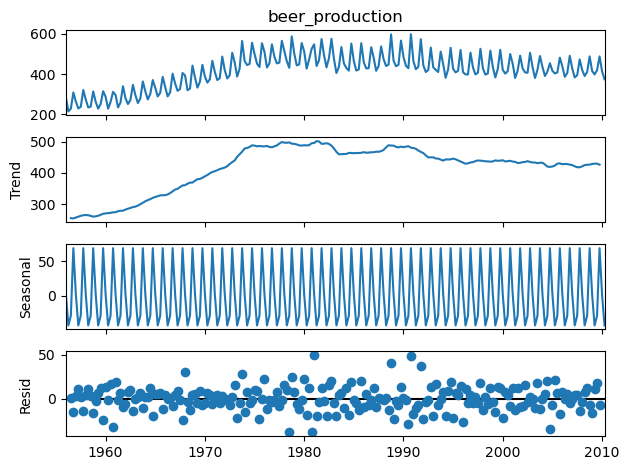

In [14]:
# Seasonal Decomposition Plots (Period = quarter), model = 'additive'
decomposition = seasonal_decompose(df['beer_production'], model='additive', period=4)
decomposition.plot()
plt.show()

#### Initial visualization of the dataset reveals clear seasonal fluctuations and long-term trends in beer production. The time series plot shows periodic peaks and troughs, indicating strong seasonal behaviour. Residual noise


## **3. Methodology and Model Development**
#### Several time series forecasting models are applied to the dataset.

### **3.1 Holt-Winters Exponential Smoothing**
#### The Holt-Winters model is used to capture both trend and seasonal components. This method is suitable for data with strong seasonality

**Train-test split, for testing use the last 20 quarters(5 years)** 

In [15]:
train = df.iloc[ :-20, :]
test  = df.iloc[-20:, :]


In [16]:
# Model building
model_HW = ExponentialSmoothing(train['beer_production'],
                                trend = 'add',
                                seasonal = 'add',
                                seasonal_periods = 4)
model_fit_HW =model_HW.fit()

In [17]:
# model predictions
predictions_HW = model_fit_HW.forecast(len(test))
predictions_HW

2005-07-01    401.697088
2005-10-01    478.226693
2006-01-01    419.433618
2006-04-01    376.928513
2006-07-01    397.963661
2006-10-01    474.493267
2007-01-01    415.700191
2007-04-01    373.195087
2007-07-01    394.230234
2007-10-01    470.759840
2008-01-01    411.966765
2008-04-01    369.461660
2008-07-01    390.496808
2008-10-01    467.026413
2009-01-01    408.233338
2009-04-01    365.728233
2009-07-01    386.763381
2009-10-01    463.292986
2010-01-01    404.499911
2010-04-01    361.994806
Freq: QS-JAN, dtype: float64

**Visualisation training, test and forecast**

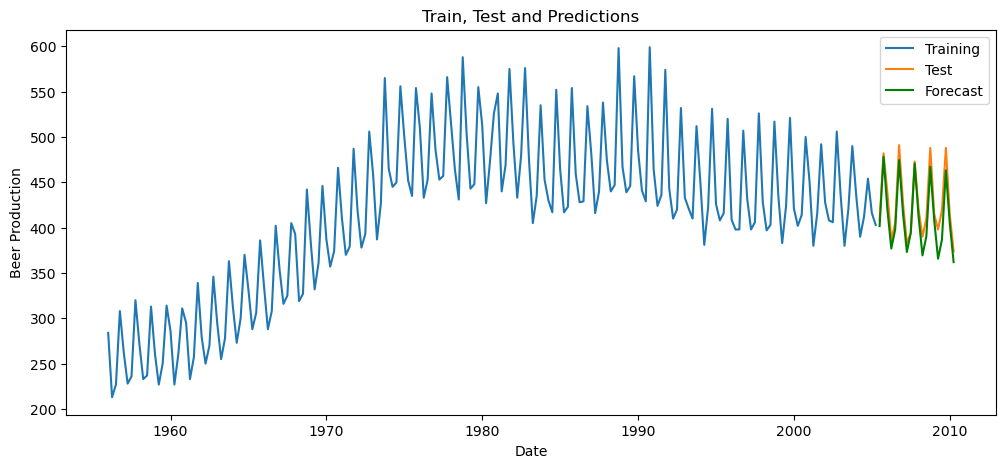

In [18]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['beer_production'], label='Training')
plt.plot(test.index, test['beer_production'], label='Test')
plt.plot(test.index, predictions_HW, color='green', label='Forecast')
plt.title("Train, Test and Predictions")
plt.xlabel('Date')
plt.ylabel('Beer Production')
plt.legend()
plt.show()

### **Summary of the model performance**

In [19]:
mae = mean_absolute_error(test['beer_production'], predictions_HW)
mse = mean_squared_error(test['beer_production'], predictions_HW)
r2 = r2_score(test['beer_production'], predictions_HW)
mape = np.mean(np.abs((test['beer_production'] - predictions_HW) / test['beer_production'])) * 100
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Pecentage Error: {mape:.2f}%")

Mean Absolute Error: 13.57
Mean Squared Error: 265.49
R-squared: 0.81
Mean Absolute Pecentage Error: 3.20%


### **3.2 ARIMA Model**
#### An AutoRegressive Integrated Moving Average (ARIMA) model is implemented to model temporal dependencies in the data. The parameters (p, d, q) are selected based on data stationarity and autocorrelation patterns.
**Parameters: p (lag order), d (degree of differencing), and q (order of moving average)**

In [20]:
# Check the stationarity of the dataset using the Augmented Dickey-Fuller (ADF) Test
df = df.copy()
from statsmodels.tsa.stattools import adfuller
result1 = adfuller(df.beer_production)
print( 'p-value: %f' % result1[1])

# Interpretation the results
if result1[1] <= 0.05:
    print('The series is stationary')
else:
    print('The series is non-stationary')


p-value: 0.090677
The series is non-stationary


In [21]:
# Difference the series to get the stationary dataset
df['beer_diff'] = df['beer_production'].diff(4)
df['beer_diff']


date
1956-01-01     NaN
1956-04-01     NaN
1956-07-01     NaN
1956-10-01     NaN
1957-01-01   -22.0
              ... 
2009-04-01     8.0
2009-07-01     9.0
2009-10-01     0.0
2010-01-01    -1.0
2010-04-01   -24.0
Freq: QS-JAN, Name: beer_diff, Length: 218, dtype: float64

In [22]:
# Check the stationarity of the differenced dataset using the Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller
result2 = adfuller(df['beer_diff'].dropna())
print( 'p-value: %f' % result2[1])

# Interpretation of the results
if result2[1] <= 0.05:
    print('The series is stationary')
else:
    print('The series is non-stationary')

p-value: 0.278018
The series is non-stationary


#### **Even though the dataset is not stationary, try the ARIMA model by identifying parameters (p,d,q) using ACF and PACF plots**
**Interpretation:**
**PACF cutoff → AR order (p),**
**ACF cutoff → MA order (q)**

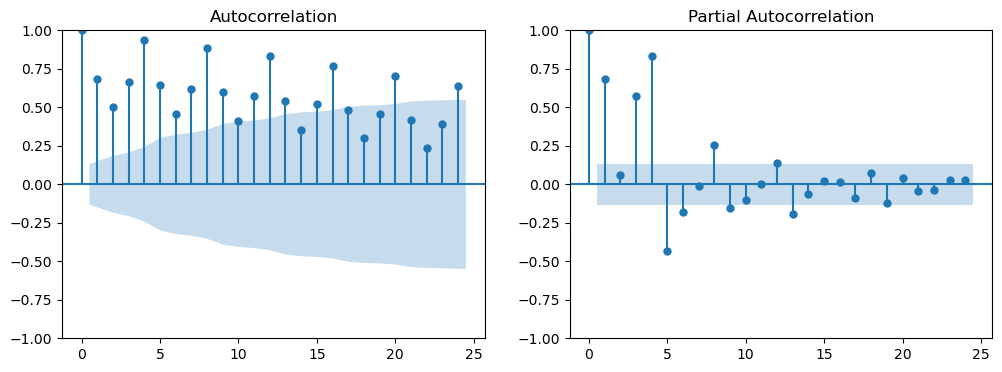

In [23]:
# ACF and PACF plots
fig, axes = plt.subplots(1,2, figsize=(12,4))

plot_acf(df['beer_production'].dropna(), ax=axes[0])
plot_pacf(df['beer_production'].dropna(), ax=axes[1])

plt.show()

In [24]:
# Check 1st ARIMA Model using parameters(2,1,3)
from statsmodels.tsa.arima.model import ARIMA
model_arima = ARIMA(train['beer_production'], order=(2,1,3))
arima_fit = model_arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        beer_production   No. Observations:                  198
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -906.327
Date:                Thu, 26 Mar 2026   AIC                           1824.654
Time:                        18:19:16   BIC                           1844.353
Sample:                    01-01-1956   HQIC                          1832.628
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0008      0.006      0.142      0.887      -0.011       0.012
ar.L2         -0.9988      0.002   -453.864      0.000      -1.003      -0.994
ma.L1         -0.8526      0.054    -15.842      0.0

C:\Users\udeni\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
# Forecast using ARIMA
forecast_arima = arima_fit.forecast(steps=len(test))

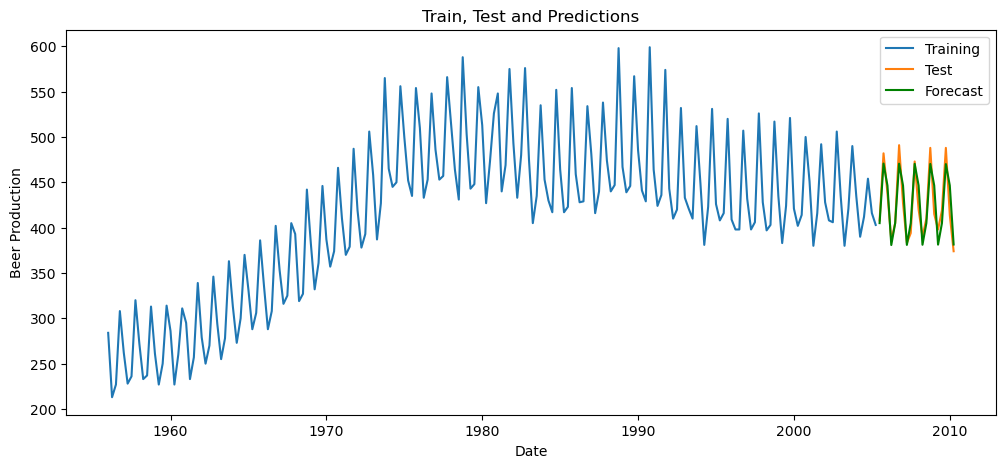

In [26]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['beer_production'], label='Training')
plt.plot(test.index, test['beer_production'], label='Test')
plt.plot(test.index, forecast_arima, color='green', label='Forecast')
plt.title("Train, Test and Predictions")
plt.xlabel('Date')
plt.ylabel('Beer Production')
plt.legend()
plt.show()

In [27]:
mae = mean_absolute_error(test['beer_production'], forecast_arima)
mse = mean_squared_error(test['beer_production'], forecast_arima)
r2 = r2_score(test['beer_production'], forecast_arima)
mape = np.mean(np.abs((test['beer_production'] - forecast_arima) / test['beer_production'])) * 100
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Pecentage Error: {mape:.2f}%")

Mean Absolute Error: 13.08
Mean Squared Error: 259.44
R-squared: 0.81
Mean Absolute Pecentage Error: 3.05%


### **3.3 SARIMA Model**
#### A Seasonal ARIMA (SARIMA) model is used to explicitly account for seasonal effects in the dataset. This model includes both non-seasonal and seasonal components.

In [28]:
# Because the data is quarterly, the seasonal period is 4
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train['beer_production'],
    order=(2,0,0),
    seasonal_order=(1,1,1,4)
)

sarima_fit = model_sarima.fit()

print(sarima_fit.summary())

# Forecast using SARIMA
forecast_sarima = sarima_fit.forecast(steps=len(test))

# Model evaluation
mae = mean_absolute_error(test['beer_production'], forecast_sarima)
mse = mean_squared_error(test['beer_production'], forecast_sarima)
r2 = r2_score(test['beer_production'], forecast_sarima)
mape = np.mean(np.abs((test['beer_production'] - forecast_sarima) / test['beer_production'])) * 100
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Pecentage Error: {mape:.2f}%")

                                      SARIMAX Results                                      
Dep. Variable:                     beer_production   No. Observations:                  198
Model:             SARIMAX(2, 0, 0)x(1, 1, [1], 4)   Log Likelihood                -829.620
Date:                             Thu, 26 Mar 2026   AIC                           1669.241
Time:                                     18:19:17   BIC                           1685.580
Sample:                                 01-01-1956   HQIC                          1675.857
                                      - 04-01-2005                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2984      0.059      5.053      0.000       0.183       0.414
ar.L2          0.5630      

#### **Residual Plot for SARIMA Model**

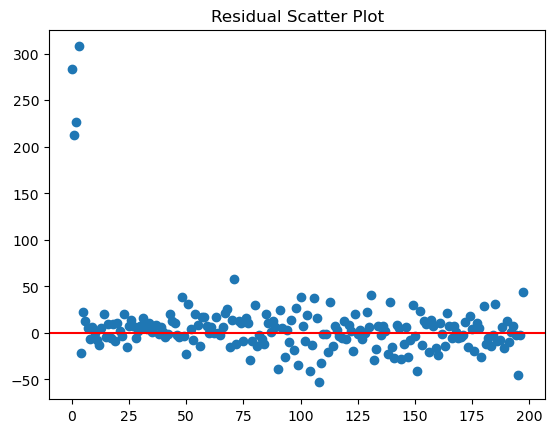

In [29]:
residuals = sarima_fit.resid

plt.scatter(range(len(residuals)), residuals)
plt.axhline(0, color ="red")
plt.title("Residual Scatter Plot")
plt.show()

#### The residuals are randomly distributed around zero with no significant autocorrelation.**

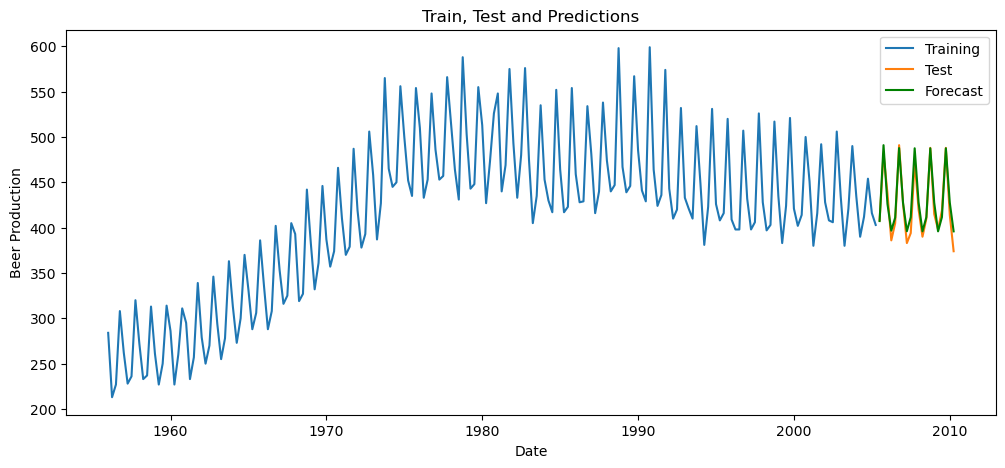

In [30]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['beer_production'], label='Training')
plt.plot(test.index, test['beer_production'], label='Test')
plt.plot(test.index, forecast_sarima, color='green', label='Forecast')
plt.title("Train, Test and Predictions")
plt.xlabel('Date')
plt.ylabel('Beer Production')
plt.legend()
plt.show()

## **4. Model Evaluation**

**The performance of each model is evaluated using Mean Absolute Percentage Error (MAPE):**

-  SARIMA: 1.95%
-  ARIMA: 3.05%
-  Holt-Winters: 3.20%

**The SARIMA model achieved the lowest error, indicating superior forecasting accuracy for this dataset.**

## **5. Results and Discussion**

**The results demonstrate that incorporating seasonality significantly improves forecasting performance. The SARIMA model outperformed both ARIMA and Holt-Winters models, suggesting that seasonal patterns play a critical role in beer production. 
The forecasts generated by the SARIMA model closely follow the observed data, capturing both upward/downward trends and seasonal variations effectively**

## **6. Forecasting**

**Using the best-performing SARIMA model, future production values for the next 2 years are forecasted.**

In [33]:
# Train the SARIMA model for the whole dataset

model_best = SARIMAX(
    df['beer_production'],
    order=(2,0,0),
    seasonal_order=(1,1,1,4)
)

best_fit = model_best.fit()

# Forecast for next 2 years (8 quarters)
forecast_steps = 8
forecast = best_fit.get_forecast(steps=forecast_steps)

# Extract forecast values
forecast_values = forecast.predicted_mean

# Confidence intervals
conf_int = forecast.conf_int()

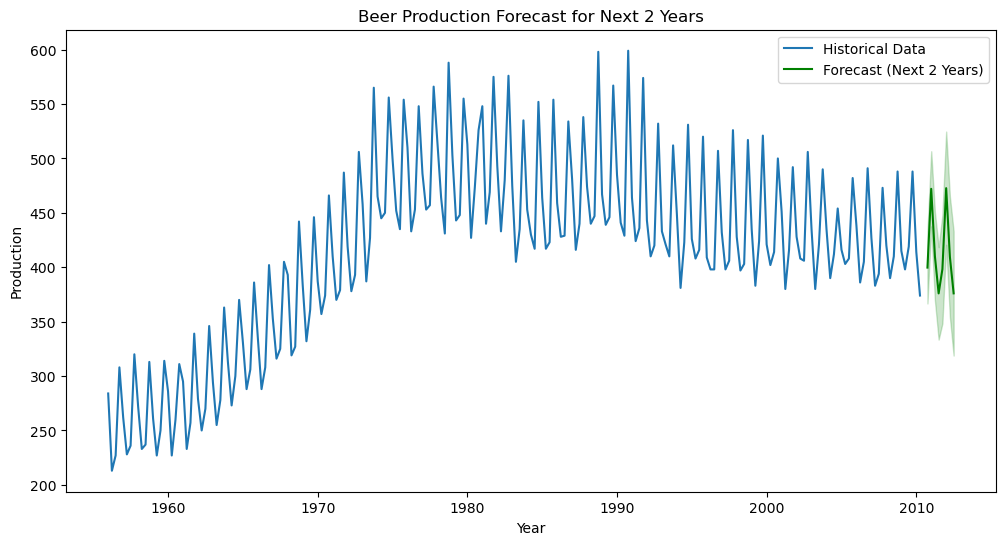

In [34]:
# Plot historical data + forecast
plt.figure(figsize=(12,6))

# Plot original data
plt.plot(df['beer_production'], label='Historical Data')

# Plot forecast
forecast_index = pd.date_range(start=df.index[-1], periods=forecast_steps+1, freq='QE')[1:]
plt.plot(forecast_index, forecast_values, label='Forecast (Next 2 Years)', color='green')

# Plot confidence intervals
plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='green', alpha=0.2)

# Labels and title
plt.title('Beer Production Forecast for Next 2 Years')
plt.xlabel('Year')
plt.ylabel('Production')
plt.legend()

plt.show()

In [35]:

# Forecast values and confidence intervals
forecast_df = pd.DataFrame({
    'Beer Production': forecast_values,
    'Lower CI': conf_int.iloc[:, 0],
    'Upper CI': conf_int.iloc[:, 1]
})

print(forecast_df)

            Beer Production    Lower CI    Upper CI
2010-07-01       399.681836  366.708571  432.655101
2010-10-01       472.069352  437.530276  506.608428
2011-01-01       410.123036  369.486088  450.759984
2011-04-01       375.978384  333.505446  418.451321
2011-07-01       398.250735  348.432498  448.068972
2011-10-01       472.687973  420.678179  524.697767
2012-01-01       409.429448  354.046476  464.812421
2012-04-01       376.005427  318.835370  433.175484


## **7. Conclusion**
**This study successfully analysed and forecasted Australian beer production using time series techniques. The findings highlight the importance of accounting for seasonality in forecasting models.
Among the models tested, SARIMA provided the most accurate predictions. The results can support decision-making in production planning and supply chain management.**